# 📘 Multimodal RAG: Chat with Text, Tables, Images & Graphs
**Tutorial & Lecture Notebook** | *Based on LangChain & Pinecone Architecture*

---

## 📌 1. The Problem: A Real PDF is Not Just Text
Enterprise documents mix **four distinct modalities** on the same page:
- 📄 **Text:** Policies, narrative descriptions, executive summaries.
- 📊 **Tables:** Financial KPIs, regional performance data.
- 🖼️ **Images:** Product hardware photos, assembly facilities.
- 📈 **Graphs & Diagrams:** Line charts, quarterly trends, supply-chain flowcharts.

### Why Traditional Text RAG Fails:
1. **Charts/Graphs:** The answer is encoded inside a visual line plot or bar chart (e.g., *"Which quarter had the highest revenue?"*).
2. **Diagrams:** Process relationships live inside boxes and arrows (e.g., *"Where is the critical quality-control point?"*).
3. **Tables:** Flattened plain text loses row-and-column alignments.

---

## 💡 2. The Multimodal Solution
Convert every modality into a retrievable text vector stored in a unified Pinecone index, while retaining the **original image path** in document metadata for final visual reasoning.

```text
PDF Document
 ├── Text         ──>  Text Chunk Document
 ├── Tables       ──>  Markdown Table Document
 └── Images/Charts ──>  Vision LLM Summary Document (metadata: image_path)
                           │
                           ▼
                    Pinecone Index
                           │
                           ▼
     Query Routing: Visual Retrieved? ──> YES: Vision LLM + Raw Image
                                     └── NO:  Text LLM + Context
```


## ⚙️ Step 1: Environment & Module Setup
Load environment variables (`GROQ_API_KEY`, `PINECONE_API_KEY`) and import LangChain, PyMuPDF (`fitz`), and Groq components.

In [64]:
# Load environment variables from .env file
import os
import io
import time
import base64
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

# PDF Processing and Data Manipulation
import fitz  # PyMuPDF for PDF text, table, and image extraction
import pandas as pd  # Used to structure extracted tables into Markdown
from PIL import Image
from IPython.display import display

# API Clients (Groq LLMs & Pinecone Vector Store)
from groq import Groq
from pinecone import Pinecone, ServerlessSpec

# LangChain Modules for Document Schema, Embeddings & Vector Stores
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_pinecone import PineconeVectorStore

print('Libraries imported successfully!')

Libraries imported successfully!


## 🛠️ Step 2: Configuration & API Initialization
Define document paths, vision/text model identifiers, embedding models, and Pinecone index names.

In [65]:
# Path to the synthetic test PDF report
PDF_PATH = Path('../NovaCore_Multimodal_Company_Report_2026.pdf')  # notebook lives in notebooks/
assert PDF_PATH.exists(), f'PDF not found at {PDF_PATH}'

# Model Specs
TEXT_MODEL = 'openai/gpt-oss-20b'           # Fast text LLM for context synthesis
VISION_MODEL = 'qwen/qwen3.8-27b'           # Multimodal vision model for image understanding
EMBEDDING_MODEL = 'sentence-transformers/all-MiniLM-L6-v2'  # Dense 384-d embeddings

# Pinecone Database Parameters (Note: Index names MUST use hyphens, not underscores)
PINECONE_INDEX_NAME = 'novacore-multimodal-rag'
PINECONE_NAMESPACE = 'fy2026-demo'

# Local directory to cache extracted PDF images
IMAGE_DIR = Path('novacore_extracted_images')
IMAGE_DIR.mkdir(exist_ok=True)

# Initialize Groq API Client and LangChain ChatGroq wrapper
groq_client = Groq(api_key=os.environ['GROQ_API_KEY'])
text_llm = ChatGroq(model=TEXT_MODEL, temperature=0)

print('Configuration initialized:')
print('  PDF Path:', PDF_PATH)
print('  Pinecone Index:', PINECONE_INDEX_NAME)
print('  Pinecone Namespace:', PINECONE_NAMESPACE)

Configuration initialized:
  PDF Path: NovaCore_Multimodal_Company_Report_2026.pdf
  Pinecone Index: novacore-multimodal-rag
  Pinecone Namespace: fy2026-demo


## 🖼️ Step 3: Visual Processing Helpers
To send images to Vision LLMs via API, we convert image files into Base64 Data URIs and prompt the Vision LLM to generate concise, factual text descriptions.

In [66]:
def image_to_data_uri(image_path):
    """Converts an image file to a Base64-encoded JPEG Data URI for API consumption."""
    image_path = Path(image_path)
    with Image.open(image_path) as img:
        img = img.convert('RGB')
        img.thumbnail((1600, 1600))
        buffer = io.BytesIO()
        img.save(buffer, format='JPEG', quality=85)
    encoded = base64.b64encode(buffer.getvalue()).decode('utf-8')
    return f'data:image/jpeg;base64,{encoded}'

def summarize_visual(image_path, page_number):
    """Prompts the Vision LLM to generate a factual, searchable summary of a chart, diagram, or photo."""
    image_data = image_to_data_uri(image_path)
    prompt = f"""
This visual was extracted from page {page_number} of the NovaCore FY2026 company report.
Describe the useful business information visible in the visual.

If it is a chart or graph:
- mention important data values and axes
- mention highest and lowest values
- describe the main overall trend

If it is a diagram:
- identify key components or stages
- explain the process flow or relationships

If it is a business image:
- describe key factual details shown

Keep the description concise, structured, and strictly factual.
"""
    response = groq_client.chat.completions.create(
        model=VISION_MODEL,
        messages=[
            {
                'role': 'user',
                'content': [
                    {'type': 'text', 'text': prompt},
                    {'type': 'image_url', 'image_url': {'url': image_data}}
                ]
            }
        ],
        temperature=0,
        max_completion_tokens=500
    )
    return response.choices[0].message.content.strip()

print('Image processing helper functions registered.')

Image processing helper functions registered.


## 📥 Step 4: Extract Text, Tables, and Visuals from PDF
We parse the PDF using PyMuPDF (`fitz`):
1. **Text:** Extracted line by line per page.
2. **Tables:** Detected via PyMuPDF table finder and formatted as **Markdown** tables to preserve grid structure.
3. **Visuals:** Extracted, saved locally, summarized via Vision LLM, and linked via `image_path` in metadata.

In [67]:
def extract_multimodal_documents(pdf_path):
    pdf = fitz.open(str(pdf_path))
    documents = []
    extracted_xrefs = set()  # Avoid processing duplicate embedded image assets

    for page_index in range(len(pdf)):
        page = pdf[page_index]
        page_number = page_index + 1
        print(f'Processing page {page_number}...')

        # 1. Narrative Text Extraction
        text = page.get_text('text').strip()
        if text:
            documents.append(
                Document(
                    page_content=text,
                    metadata={
                        'page': page_number,
                        'modality': 'text',
                        'source': pdf_path.name
                    }
                )
            )

        # 2. Table Extraction (Preserving Row/Column Structure via Markdown)
        try:
            tables = page.find_tables().tables
            for table_number, table in enumerate(tables, start=1):
                df = table.to_pandas()
                if not df.empty:
                    table_text = df.to_markdown(index=False)
                    documents.append(
                        Document(
                            page_content=table_text,
                            metadata={
                                'page': page_number,
                                'modality': 'table',
                                'table_number': table_number,
                                'source': pdf_path.name
                            }
                        )
                    )
        except Exception as error:
            print('Table extraction warning:', error)

        # 3. Image/Chart/Diagram Extraction & Vision LLM Summarization
        for image_number, image_info in enumerate(page.get_images(full=True), start=1):
            xref = image_info[0]
            if xref in extracted_xrefs:
                continue
            extracted_xrefs.add(xref)

            image_data = pdf.extract_image(xref)
            image_bytes = image_data['image']
            image_extension = image_data['ext']
            image_path = IMAGE_DIR / f'page_{page_number}_image_{image_number}.{image_extension}'
            image_path.write_bytes(image_bytes)

            try:
                summary = summarize_visual(image_path=image_path, page_number=page_number)
                documents.append(
                    Document(
                        page_content=summary,
                        metadata={
                            'page': page_number,
                            'modality': 'visual',
                            'image_path': str(image_path),
                            'source': pdf_path.name
                        }
                    )
                )
            except Exception as error:
                print(f'Vision summary warning on page {page_number}:', error)

    pdf.close()
    return documents

# Run the multimodal extraction pipeline
documents = extract_multimodal_documents(PDF_PATH)
print(f'\nTotal LangChain documents extracted: {len(documents)}')

Processing page 1...
Processing page 2...
Processing page 3...
Processing page 4...
Processing page 5...
Processing page 6...
Processing page 7...
Processing page 8...
Processing page 9...

Total LangChain documents extracted: 24


## 📊 Step 5: Inspect Extracted Document Modalities
Let's break down the extracted documents by modality type (`text`, `table`, `visual`).

In [68]:
rows = []
for doc in documents:
    rows.append({
        'page': doc.metadata['page'],
        'modality': doc.metadata['modality'],
        'preview': doc.page_content[:120].replace('\n', ' ')
    })

summary_df = pd.DataFrame(rows)
display(summary_df.head(10))

print('Documents count by modality:')
display(summary_df['modality'].value_counts())

,page,modality,preview
0,1,text,NovaCore Systems Ltd. - Fictional company repo...
1,1,table,| Headquarters | Singapore | Emplo...
2,1,visual,"Based on the visual provided, here is the usef..."
3,2,text,NovaCore Systems Ltd. - Fictional company repo...
4,2,table,| Priority | 2026 target ...
5,3,text,NovaCore Systems Ltd. - Fictional company repo...
6,3,table,| Metric | FY2025 | FY2026 | Cha...
7,3,visual,"Based on the visual provided, here is the desc..."
8,4,text,NovaCore Systems Ltd. - Fictional company repo...
9,4,table,| Region | 2026 revenue | YoY growth ...


Documents count by modality:


modality
text      9
table     8
visual    7
Name: count, dtype: int64

## 🤗 Step 6: Create Text Embeddings
We initialize Hugging Face `sentence-transformers/all-MiniLM-L6-v2` to generate 384-dimensional dense vectors for all document types.

In [69]:
# Initialize HuggingFace embeddings
embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    encode_kwargs={'normalize_embeddings': True}
)

# Verify the exact embedding vector dimension
EMBEDDING_DIMENSION = len(embeddings.embed_query('dimension check'))
print('Embedding Model:', EMBEDDING_MODEL)
print('Vector Dimension:', EMBEDDING_DIMENSION)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10084.34it/s]


Embedding Model: sentence-transformers/all-MiniLM-L6-v2
Vector Dimension: 384


## 🌲 Step 7: Pinecone Vector Database Setup & Ingestion

```text
LangChain Documents (Text, Markdown Tables, Visual Summaries)
        ↓
Hugging Face Embeddings (384-d vectors)
        ↓
PineconeVectorStore (Index: novacore-multimodal-rag, Namespace: fy2026-demo)
```

In [70]:
pc = Pinecone(api_key=os.environ['PINECONE_API_KEY'])

# Create serverless index if it doesn't exist
if not pc.has_index(PINECONE_INDEX_NAME):
    print('Creating Pinecone Index...')
    pc.create_index(
        name=PINECONE_INDEX_NAME,
        dimension=EMBEDDING_DIMENSION,
        metric='cosine',
        spec=ServerlessSpec(cloud='aws', region='us-east-1')
    )
    while not pc.describe_index(PINECONE_INDEX_NAME).status['ready']:
        print('Waiting for index to be ready...')
        time.sleep(2)
    print('Pinecone index created successfully!')
else:
    print('Pinecone index already exists.')

index = pc.Index(PINECONE_INDEX_NAME)

# Clean existing namespace vectors before uploading to prevent duplicate entries from multiple cell executions
try:
    index.delete(delete_all=True, namespace=PINECONE_NAMESPACE)
    print('Cleared existing vectors in namespace:', PINECONE_NAMESPACE)
except Exception as err:
    print('Namespace was empty or fresh. Proceeding...')

# Wrap with LangChain PineconeVectorStore and upload documents
vectorStore = PineconeVectorStore(
    index_name=PINECONE_INDEX_NAME,
    embedding=embeddings,
    namespace=PINECONE_NAMESPACE
)

# Upsert clean documents
vectorStore.add_documents(documents)
print('All multimodal documents successfully stored in Pinecone!')

# Create similarity retriever
retriever = vectorStore.as_retriever(search_kwargs={'k': 5})

Creating Pinecone Index...
Pinecone index created successfully!
Namespace was empty or fresh. Proceeding...
All multimodal documents successfully stored in Pinecone!


## 🤖 Step 8: Complete Multimodal RAG & Query Routing
We build a smart routing function `ask_rag(question)`:
1. Retrieves top-5 relevant documents from Pinecone.
2. Deduplicates retrieved `image_path` references to prevent identical images from displaying multiple times.
3. If **no visuals**, routes context + question to the **Text LLM**.
4. If **visuals present**, loads unique image files and routes context + question + **raw images** to the **Vision LLM**.

In [71]:
# 1. Text RAG Prompt & Chain
text_rag_prompt = ChatPromptTemplate.from_template("""
You are a helpful assistant answering questions about the NovaCore Systems FY2026 report.

Use ONLY the retrieved context below.
If the answer is not available in the context, say: "I could not find that information in the report."
Mention page numbers when possible.

CONTEXT:
{context}

QUESTION:
{question}

ANSWER:
""")

text_rag_chain = text_rag_prompt | text_llm | StrOutputParser()

def format_context(retrieved_docs):
    parts = []
    for doc in retrieved_docs:
        page = doc.metadata.get('page')
        modality = doc.metadata.get('modality')
        parts.append(f"[Page: {page} | {modality.upper()}]\n{doc.page_content}")
    return "\n\n".join(parts)

def answer_with_vision(question, context, image_paths):
    """Invokes Vision LLM with retrieved text context and unique visual image files."""
    image_paths = image_paths[:1]  # Limit to 1 primary visual to remain cleanly within Groq API token limits
    content = [
        {
            'type': 'text',
            'text': f"""
You are answering questions about the NovaCore Systems FY2026 report.
Use ONLY the retrieved context and attached visuals.

RETRIEVED CONTEXT:
{context}

QUESTION:
{question}

Instructions:
- Answer factually using evidence from the text and attached images.
- Mention page numbers.
- If missing, state that it is not found.
"""
        }
    ]
    for img_path in image_paths:
        content.append({
            'type': 'image_url',
            'image_url': {'url': image_to_data_uri(img_path)}
        })

    response = groq_client.chat.completions.create(
        model=VISION_MODEL,
        messages=[{'role': 'user', 'content': content}],
        temperature=0,
        max_completion_tokens=900
    )
    return response.choices[0].message.content.strip()

def ask_rag(question, show_resources=True, show_images=False):
    """Main entry point for answering questions across text, tables, and visuals."""
    retrieved_docs = retriever.invoke(question)
    context = format_context(retrieved_docs)
    
    # Extract visual assets from metadata with DEDUPLICATION to prevent identical images from appearing twice
    image_paths = []
    for doc in retrieved_docs:
        if doc.metadata.get('modality') == 'visual':
            img_p = doc.metadata.get('image_path')
            if img_p and Path(img_p).exists() and img_p not in image_paths:
                image_paths.append(img_p)

    # Route to Vision LLM or Text LLM
    if image_paths:
        answer = answer_with_vision(question=question, context=context, image_paths=image_paths)
    else:
        answer = text_rag_chain.invoke({'context': context, 'question': question})

    print('\n' + '='*60)
    print('❓ QUESTION:', question)
    print('💡 ANSWER:\n', answer)
    
    if show_resources:
        print('\n📌 RETRIEVED SOURCES:')
        for i, doc in enumerate(retrieved_docs, start=1):
            print(f"  {i}. Page {doc.metadata.get('page')} | Modality: {doc.metadata.get('modality')}")
            
    if show_images and image_paths:
        print('\n🖼️ RETRIEVED VISUAL ASSETS (Unique Only):')
        for img_p in image_paths:
            display(Image.open(img_p))

    return {'answer': answer, 'documents': retrieved_docs, 'image_paths': image_paths}

print('Multimodal RAG pipeline ready!')

Multimodal RAG pipeline ready!


### 🧪 Example 1: Text Retrieval
**Question:** *"What does NovaCore Systems do and where is the company headquartered?"*

*Lecture Slide 6 Reference: Facts exist in narrative text paragraphs.*

In [72]:
ask_rag('What does NovaCore Systems do and where is the company headquartered?')


❓ QUESTION: What does NovaCore Systems do and where is the company headquartered?
💡 ANSWER:
 NovaCore Systems Ltd. develops industrial AI gateways, computer‑vision appliances, and connected sensor hubs that serve manufacturing, logistics, and energy companies【Page: 2.0 | TEXT】. The company is headquartered in Singapore【Page: 1.0 | TEXT】.

📌 RETRIEVED SOURCES:
  1. Page 6.0 | Modality: text
  2. Page 1.0 | Modality: text
  3. Page 8.0 | Modality: text
  4. Page 2.0 | Modality: text
  5. Page 5.0 | Modality: text


{'answer': 'NovaCore Systems Ltd. develops industrial AI gateways, computer‑vision appliances, and connected sensor hubs that serve manufacturing, logistics, and energy companies【Page: 2.0 | TEXT】. The company is headquartered in Singapore【Page: 1.0 | TEXT】.',
 'documents': [Document(id='060537f9-0cba-449f-84bc-507aabf03172', metadata={'modality': 'text', 'page': 6.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='NovaCore Systems Ltd. - Fictional company report created for a multimodal RAG demonstration\nPage 6\n5. Manufacturing & Supply Chain\nInformation-bearing diagram + facility image\nThe supply-chain diagram above contains operational details that are not repeated in full elsewhere. In particular, it\nidentifies the Quality Lab in Singapore as the critical control point before products move to regional distribution\nhubs.\nFigure 3. Penang Smart Assembly Facility. The embedded image carries facility utilization and solar contribution values that can be\n

### 🧪 Example 2: Table Retrieval
**Question:** *"Which region had the highest year-over-year revenue growth?"*

*Lecture Slide 7 Reference: Markdown tables maintain row/column alignment.*

In [73]:
ask_rag('Which region had the highest year-over-year revenue growth?')


❓ QUESTION: Which region had the highest year-over-year revenue growth?
💡 ANSWER:
 Based on the visual chart and table on **Page 4.0**, the region with the highest year-over-year revenue growth is **Europe**, with a growth rate of **31%**.

This is also confirmed in the table on **Page 2.0**, which lists the "European expansion" priority as "Achieved: 31%".

📌 RETRIEVED SOURCES:
  1. Page 4.0 | Modality: visual
  2. Page 4.0 | Modality: table
  3. Page 2.0 | Modality: table
  4. Page 3.0 | Modality: visual
  5. Page 3.0 | Modality: table


{'answer': 'Based on the visual chart and table on **Page 4.0**, the region with the highest year-over-year revenue growth is **Europe**, with a growth rate of **31%**.\n\nThis is also confirmed in the table on **Page 2.0**, which lists the "European expansion" priority as "Achieved: 31%".',
 'documents': [Document(id='ac545cc6-f834-4da8-b49b-190ee629f2a8', metadata={'image_path': 'novacore_extracted_images/page_4_image_1.png', 'modality': 'visual', 'page': 4.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='Based on the visual provided, here is the description of the business information:\n\n**Chart Type:** Vertical Bar Chart\n\n**Title:** 2026 Year-over-Year Revenue Growth by Region\n\n**Axes:**\n*   **Y-Axis:** Represents "Growth (%)" with a scale ranging from 0 to 35.\n*   **X-Axis:** Represents four distinct geographic regions.\n\n**Data Values:**\nThe chart displays the specific year-over-year revenue growth percentage for each region:\n*   **Europe:** 31

### 🧪 Example 3: Graph / Chart Retrieval
**Question:** *"According to the revenue growth graph, which quarter had the highest revenue?"*

*Lecture Slide 8 Reference: Answer is inside the quarterly revenue line chart image.*


❓ QUESTION: According to the revenue growth graph, which quarter had the highest revenue?
💡 ANSWER:
 Based on the "Quarterly Revenue Trend" line graph on **Page 3.0**, the quarter with the highest revenue is **Q4 2026**.

The graph shows a consistent upward trend, with the data point for Q4 2026 reaching the highest value on the chart, approximately **$37.5 million**.

📌 RETRIEVED SOURCES:
  1. Page 3.0 | Modality: visual
  2. Page 4.0 | Modality: visual
  3. Page 4.0 | Modality: table
  4. Page 3.0 | Modality: table
  5. Page 3.0 | Modality: text

🖼️ RETRIEVED VISUAL ASSETS (Unique Only):


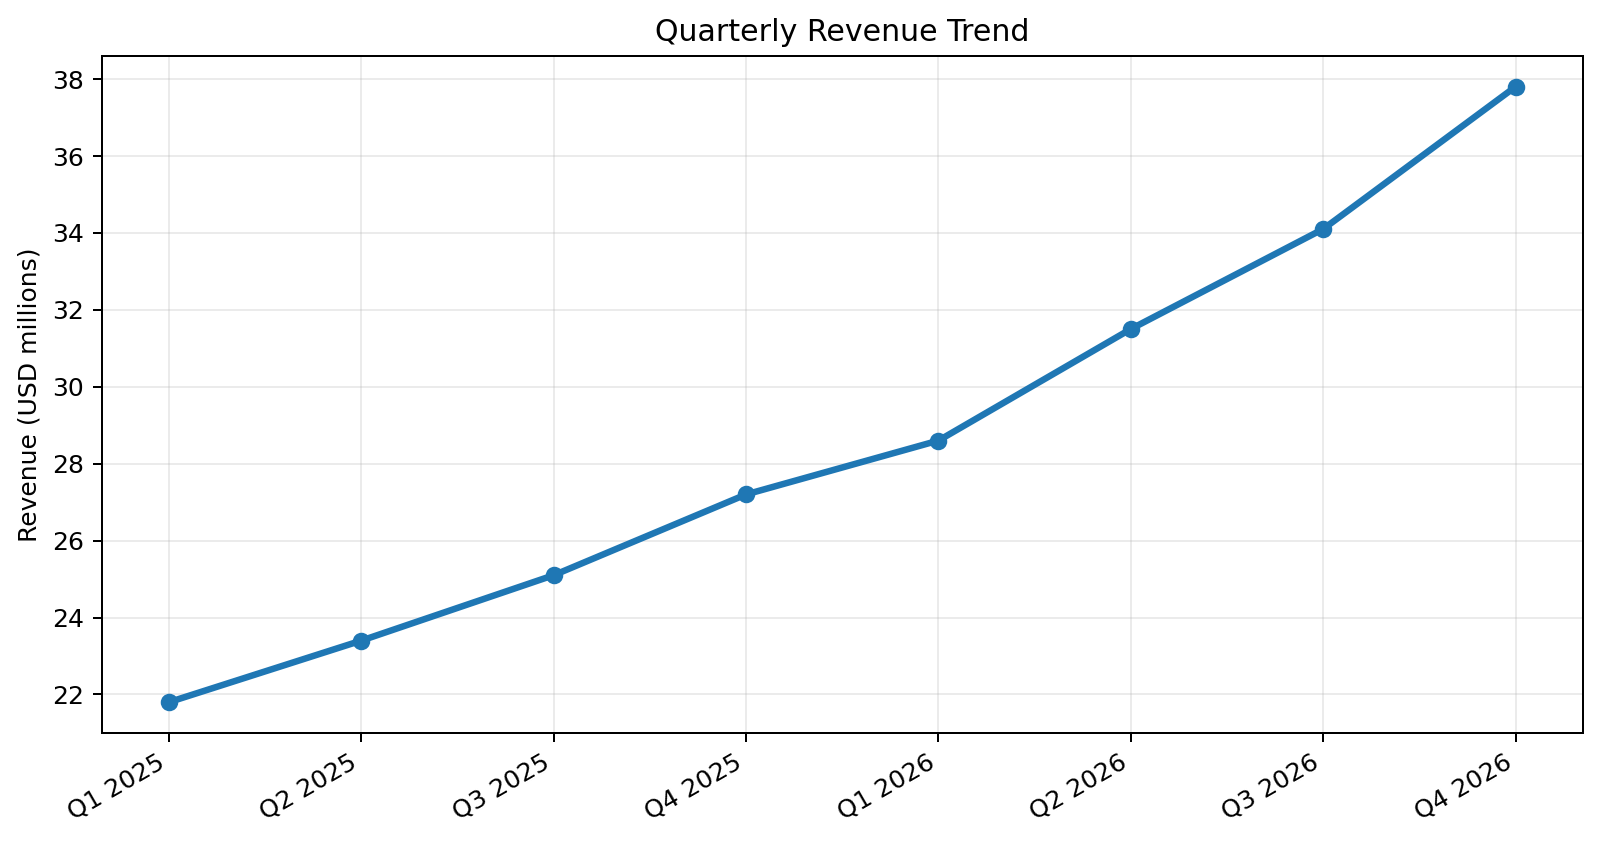

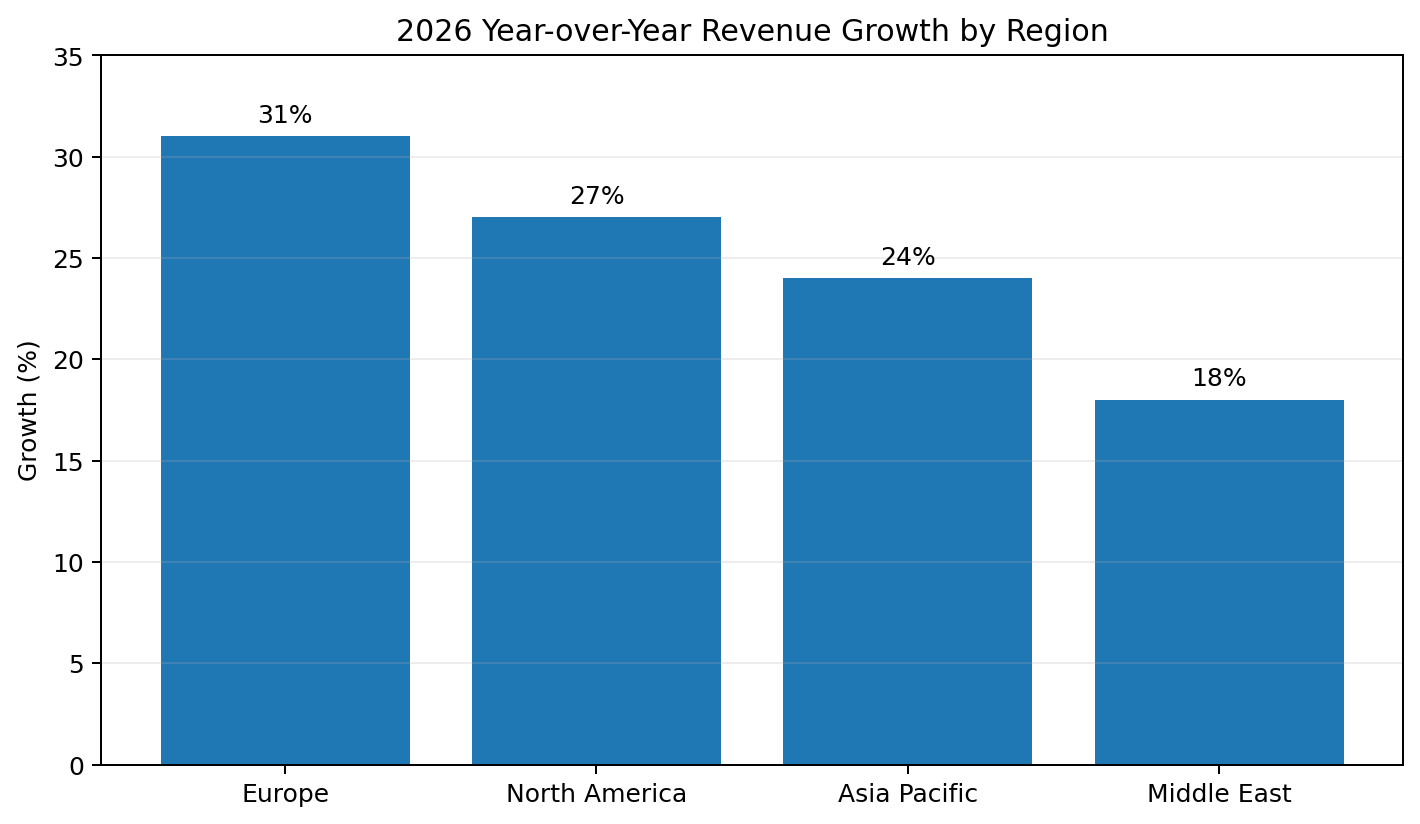

{'answer': 'Based on the "Quarterly Revenue Trend" line graph on **Page 3.0**, the quarter with the highest revenue is **Q4 2026**.\n\nThe graph shows a consistent upward trend, with the data point for Q4 2026 reaching the highest value on the chart, approximately **$37.5 million**.',
 'documents': [Document(id='91bb7c7e-5264-43f8-b7c9-447266f87ea1', metadata={'image_path': 'novacore_extracted_images/page_3_image_1.png', 'modality': 'visual', 'page': 3.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='Based on the visual provided, here is the description of the business information:\n\n**Chart Type:** Line Graph\n\n**Title:** Quarterly Revenue Trend\n\n**Axes:**\n*   **X-Axis (Horizontal):** Represents time in quarters, spanning from Q1 2025 to Q4 2026.\n*   **Y-Axis (Vertical):** Represents Revenue in USD millions, with a scale ranging from 22 to 38.\n\n**Data Points & Values:**\n*   **Q1 2025:** ~22 million (Lowest value)\n*   **Q2 2025:** ~23.5 million\n*   

In [74]:
ask_rag('According to the revenue growth graph, which quarter had the highest revenue?', show_images=True)

### 🧪 Example 4: Diagram Retrieval
**Question:** *"According to the supply-chain diagram, where is the critical quality-control point?"*

*Lecture Slide 9 Reference: Process flow & critical control point live in box-and-arrow diagrams.*


❓ QUESTION: According to the supply-chain diagram, where is the critical quality-control point?
💡 ANSWER:
 Based on the supply-chain diagram and the accompanying text on **Page 6.0**, the critical quality-control point is the **Quality Lab** located in **Singapore**.

The diagram explicitly labels the "Quality Lab" box with the location "Singapore" and includes a highlighted note stating: "Critical control point: Quality Lab." The text on the same page confirms this, stating, "it identifies the Quality Lab in Singapore as the critical control point before products move to regional distribution hubs."

📌 RETRIEVED SOURCES:
  1. Page 6.0 | Modality: visual
  2. Page 6.0 | Modality: text
  3. Page 9.0 | Modality: table
  4. Page 7.0 | Modality: table
  5. Page 3.0 | Modality: visual

🖼️ RETRIEVED VISUAL ASSETS (Unique Only):


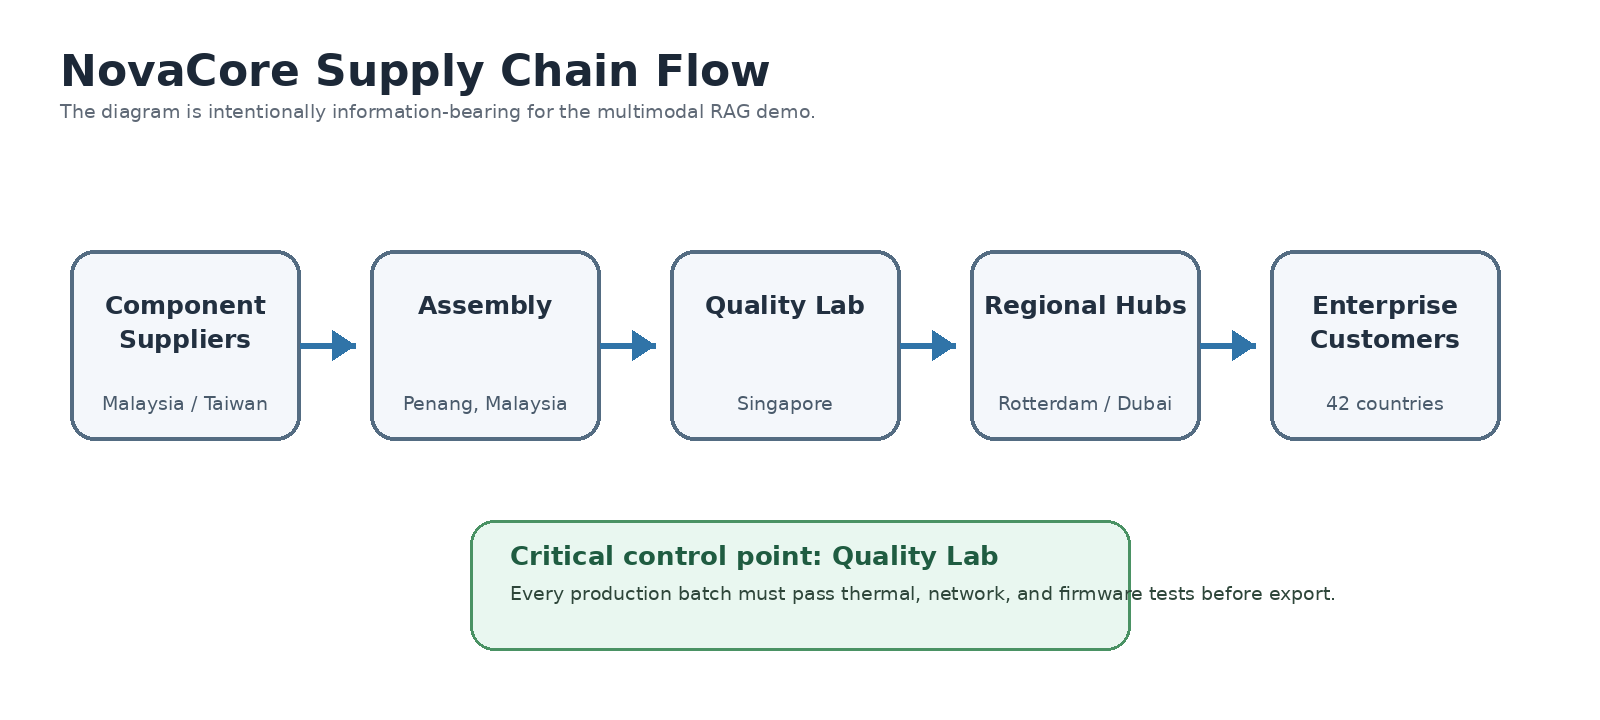

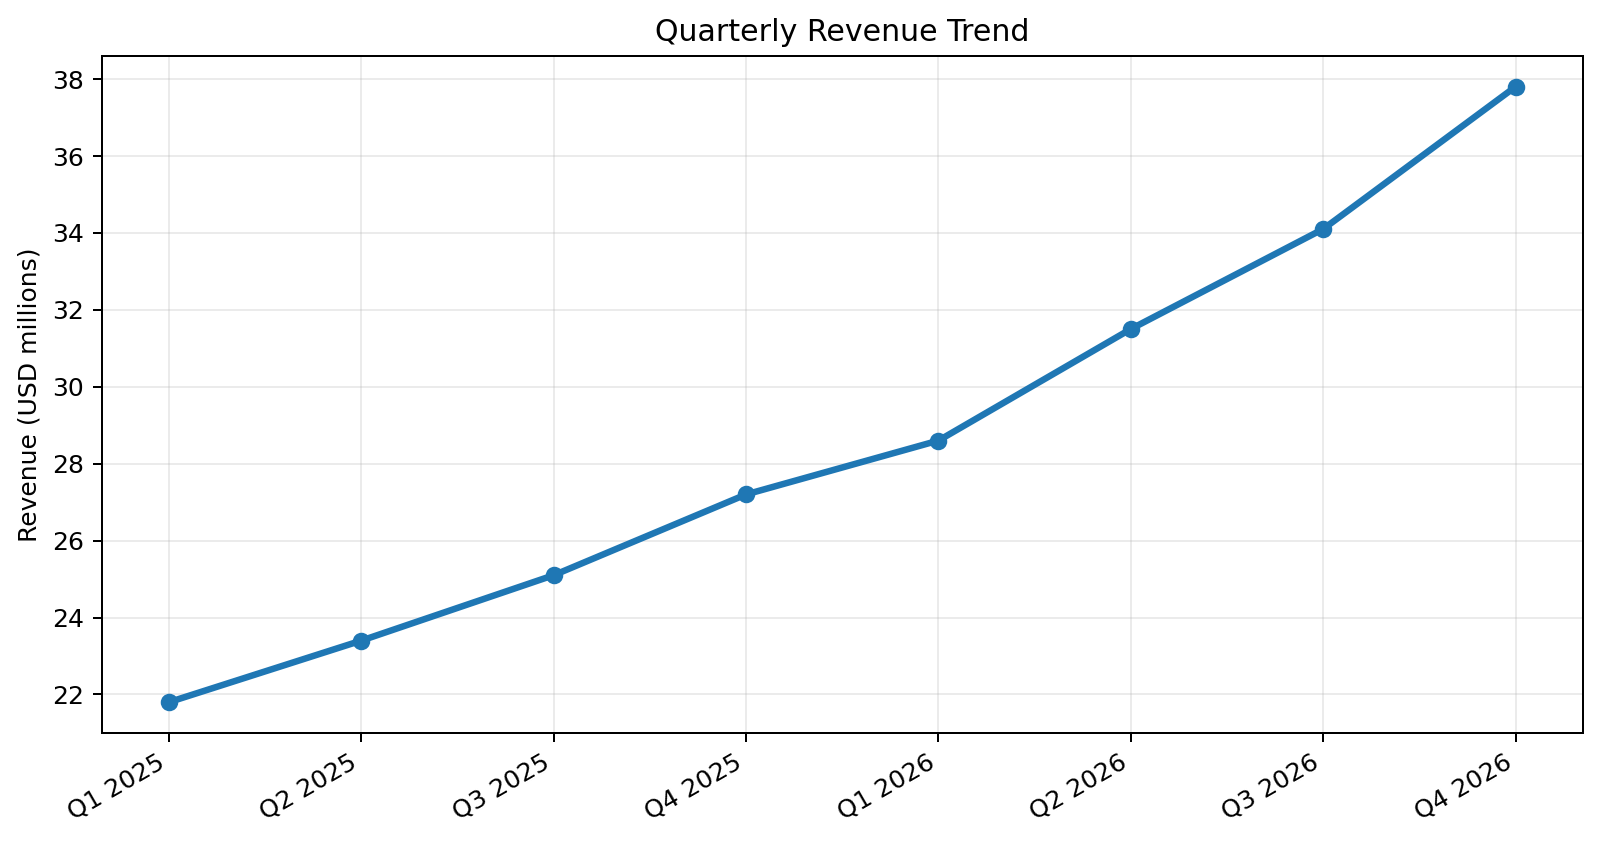

{'answer': 'Based on the supply-chain diagram and the accompanying text on **Page 6.0**, the critical quality-control point is the **Quality Lab** located in **Singapore**.\n\nThe diagram explicitly labels the "Quality Lab" box with the location "Singapore" and includes a highlighted note stating: "Critical control point: Quality Lab." The text on the same page confirms this, stating, "it identifies the Quality Lab in Singapore as the critical control point before products move to regional distribution hubs."',
 'documents': [Document(id='18ac7674-44ce-4f2b-b0d4-fe4cc282d252', metadata={'image_path': 'novacore_extracted_images/page_6_image_1.png', 'modality': 'visual', 'page': 6.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='Based on the visual provided, here is the description of the business information:\n\n**Diagram Type:** Process Flow Diagram\n\n**Title:** NovaCore Supply Chain Flow\n\n**Process Flow & Key Components:**\nThe diagram illustrates a linear

In [75]:
ask_rag('According to the supply-chain diagram, where is the critical quality-control point?', show_images=True)

### 🧪 Example 5: Pie Chart Retrieval
**Question:** *"What percentage of the Penang facility electricity came from solar energy?"*

*Lecture Slide 10 Reference: Proportional pie chart queries.*


❓ QUESTION: What percentage of the Penang facility electricity came from solar energy?
💡 ANSWER:
 Based on the retrieved context and visuals, **34%** of the Penang facility's electricity came from solar energy in FY2026.

This is confirmed by:
- The pie chart on **Page 8.0**, which shows "Solar" at 34%.
- The text on **Page 8.0**, which states: "Solar supplied 34% of electricity..."
- The facility overview on **Page 1.0**, which lists "Solar Contribution to Electricity: 34%".

📌 RETRIEVED SOURCES:
  1. Page 8.0 | Modality: visual
  2. Page 1.0 | Modality: visual
  3. Page 8.0 | Modality: text
  4. Page 8.0 | Modality: table
  5. Page 1.0 | Modality: table

🖼️ RETRIEVED VISUAL ASSETS (Unique Only):


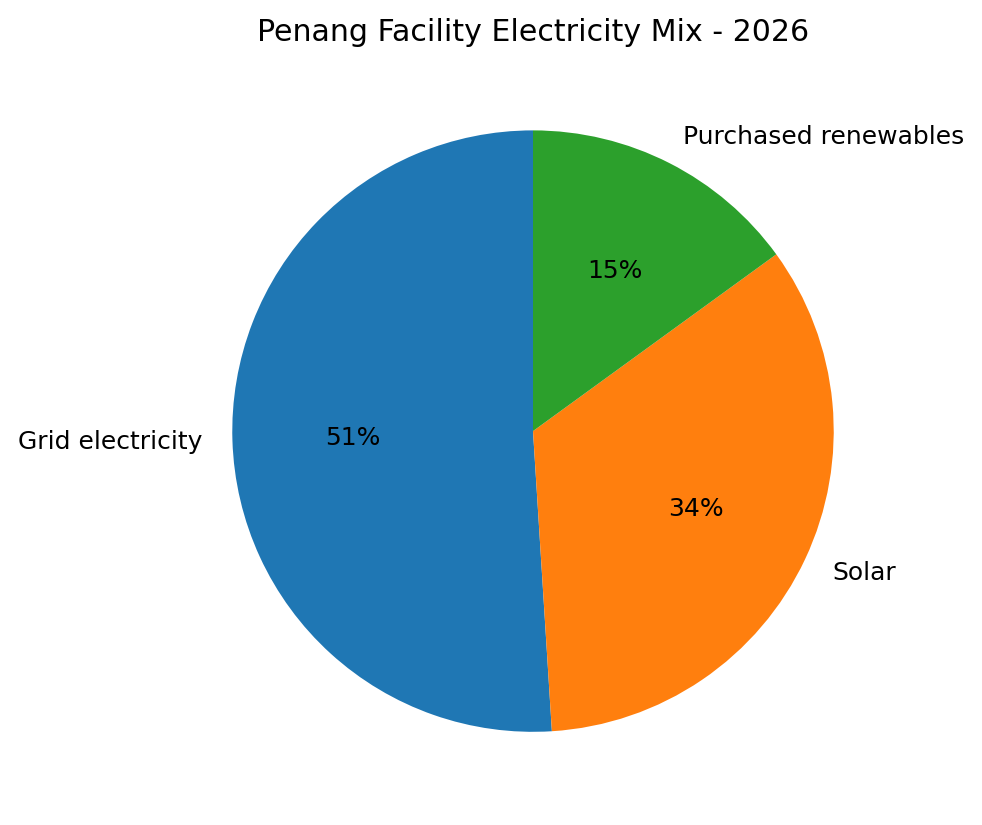

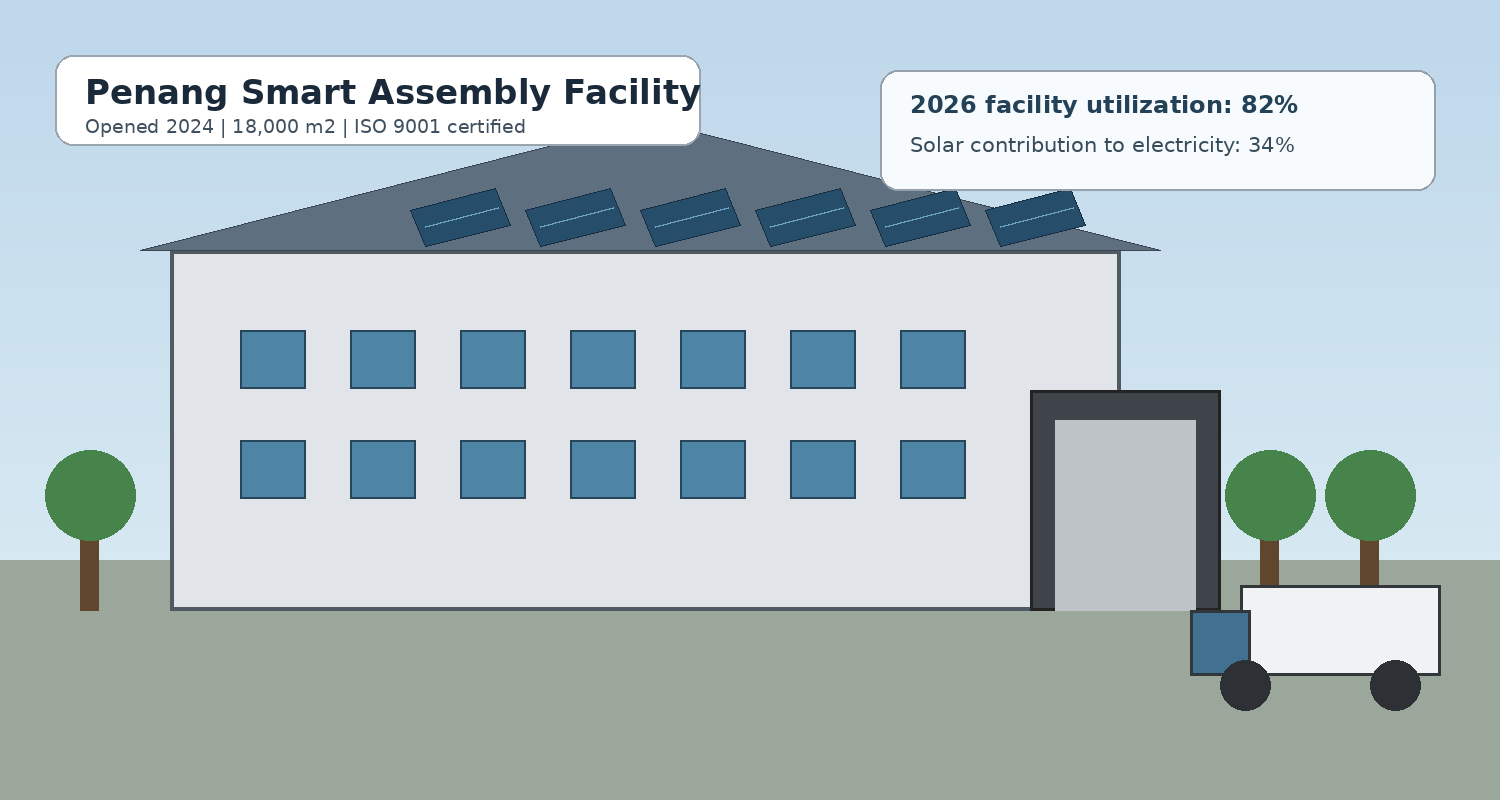

{'answer': 'Based on the retrieved context and visuals, **34%** of the Penang facility\'s electricity came from solar energy in FY2026.\n\nThis is confirmed by:\n- The pie chart on **Page 8.0**, which shows "Solar" at 34%.\n- The text on **Page 8.0**, which states: "Solar supplied 34% of electricity..."\n- The facility overview on **Page 1.0**, which lists "Solar Contribution to Electricity: 34%".',
 'documents': [Document(id='04740474-532d-4447-9e65-cfb3e53d3f0c', metadata={'image_path': 'novacore_extracted_images/page_8_image_1.png', 'modality': 'visual', 'page': 8.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content="Based on the visual provided, here is the description of the business information:\n\n**Chart Type:** Pie Chart\n**Title:** Penang Facility Electricity Mix - 2026\n\n**Data Breakdown:**\nThe chart illustrates the projected sources of electricity for the Penang facility in the fiscal year 2026, divided into three categories:\n\n*   **Grid electricity

In [76]:
ask_rag('What percentage of the Penang facility electricity came from solar energy?', show_images=True)

### 🧪 Example 6: Hybrid Cross-Modal Query (Combined Text & Visual Context)
**Question:** *"Which product is listed in the product table as having the highest gross margin, and what visual details/highlights are shown about it in its product image?"*

*Key Concept: The system retrieves both the tabular specs and the raw image, enabling the Vision LLM to synthesize structured text facts alongside visual hardware characteristics.*


❓ QUESTION: Which product is listed in the table as having the highest gross margin, and what details are highlighted about it in the product visual?
💡 ANSWER:
 Based on the retrieved context and visuals, the product with the highest gross margin is the **AtlasEdge X1**.

**Details highlighted in the product visual (Page 5.0):**
*   **Product Name:** AtlasEdge X1
*   **Category:** AI edge gateway
*   **Financial Metric:** 46% gross margin
*   **Visual Icon:** A dark grey rectangular device with a blue screen and four green indicator lights at the bottom.
*   **Specific Annotation:** A note at the bottom of the visual explicitly states: "Note: AtlasEdge X1 is the highest-margin product in the 2026 portfolio."

📌 RETRIEVED SOURCES:
  1. Page 5.0 | Modality: visual
  2. Page 3.0 | Modality: visual
  3. Page 3.0 | Modality: text
  4. Page 4.0 | Modality: visual
  5. Page 9.0 | Modality: text

🖼️ RETRIEVED VISUAL ASSETS (Unique Only):


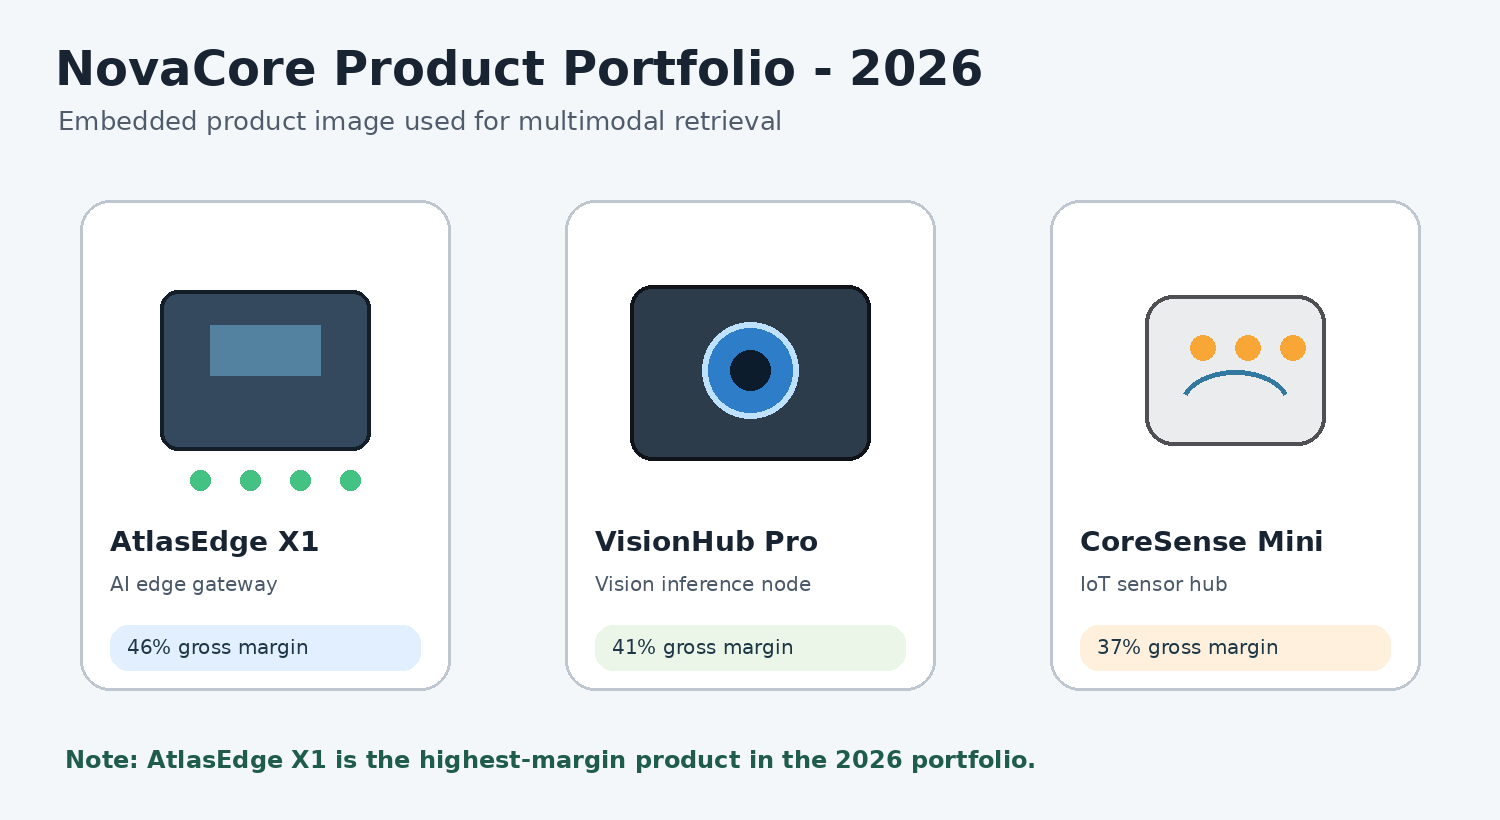

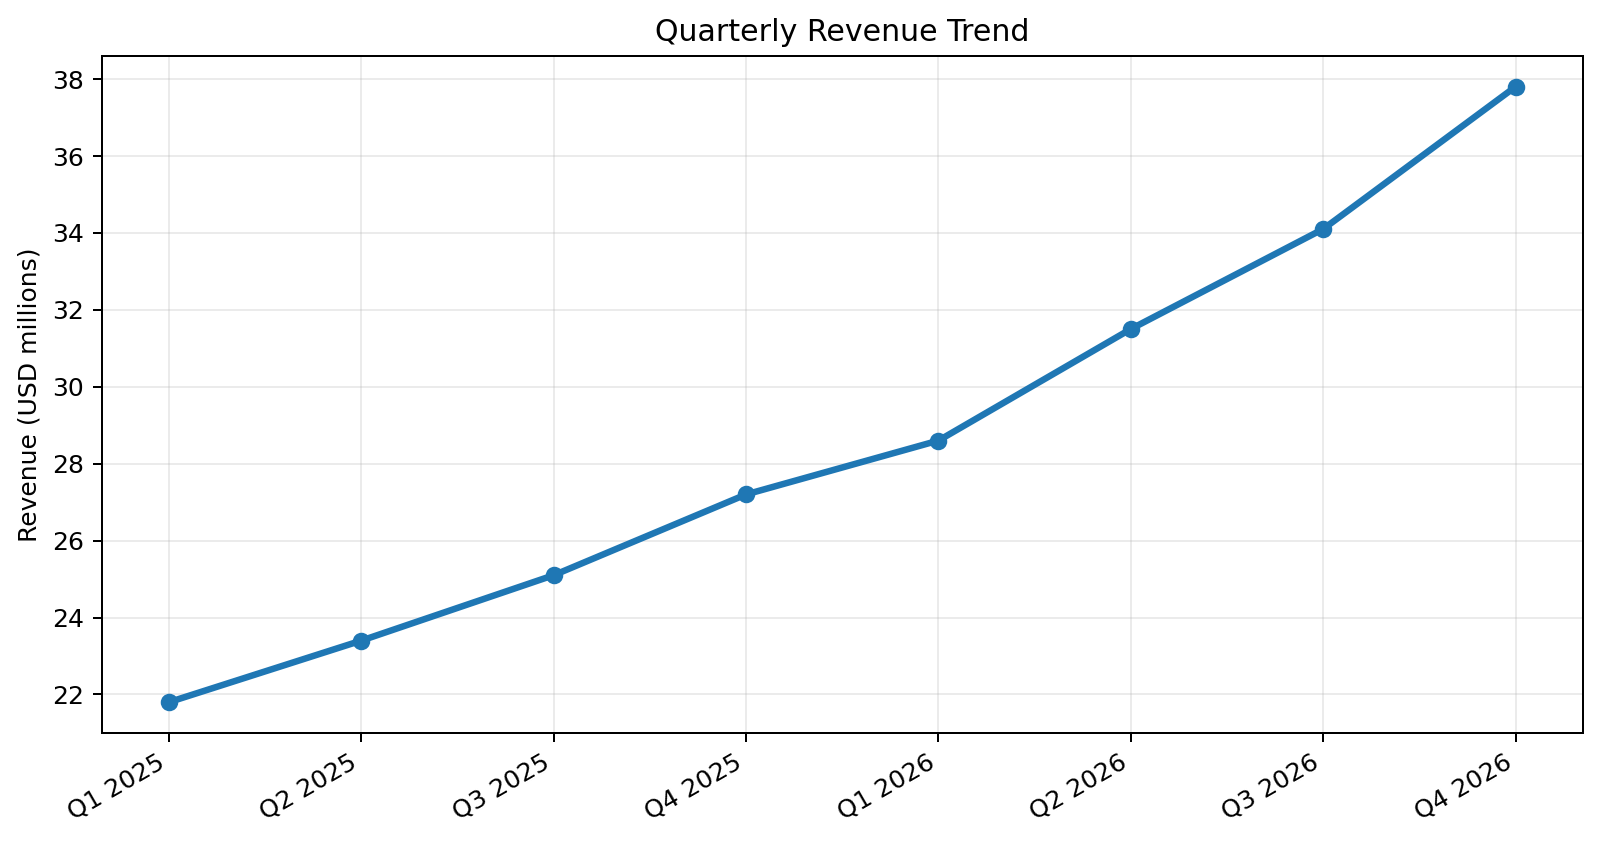

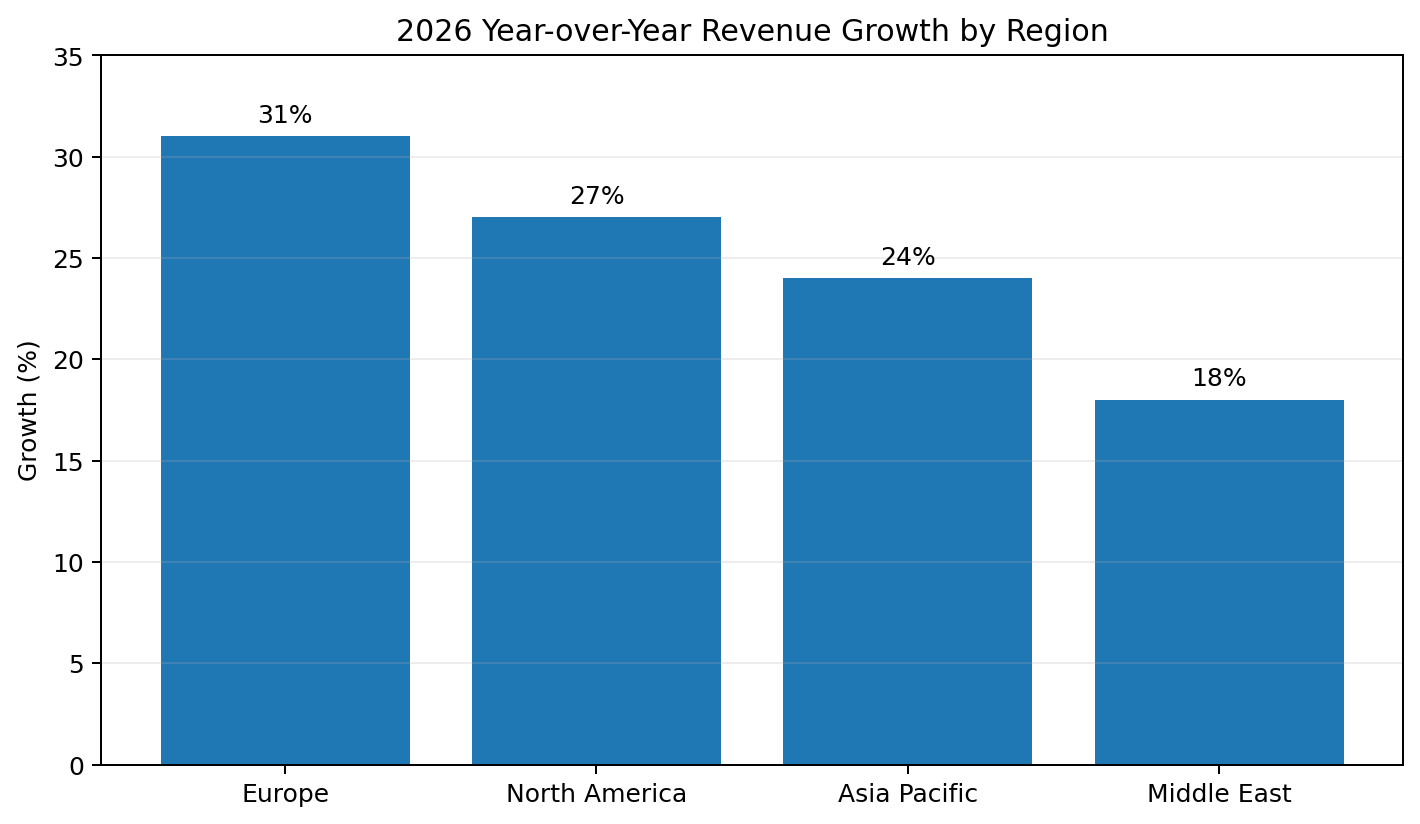

{'answer': 'Based on the retrieved context and visuals, the product with the highest gross margin is the **AtlasEdge X1**.\n\n**Details highlighted in the product visual (Page 5.0):**\n*   **Product Name:** AtlasEdge X1\n*   **Category:** AI edge gateway\n*   **Financial Metric:** 46% gross margin\n*   **Visual Icon:** A dark grey rectangular device with a blue screen and four green indicator lights at the bottom.\n*   **Specific Annotation:** A note at the bottom of the visual explicitly states: "Note: AtlasEdge X1 is the highest-margin product in the 2026 portfolio."',
 'documents': [Document(id='1a310c8d-e8db-4eab-9c21-725af288ce91', metadata={'image_path': 'novacore_extracted_images/page_5_image_1.png', 'modality': 'visual', 'page': 5.0, 'source': 'NovaCore_Multimodal_Company_Report_2026.pdf'}, page_content='Based on the visual provided, here is the description of the business information:\n\n**Visual Type:** Business Diagram / Product Portfolio Overview\n\n**Key Components:**\nThe

In [77]:
ask_rag(
    'Which product is listed in the table as having the highest gross margin, and what details are highlighted about it in the product visual?',
    show_images=True
)